In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\rasik\Downloads\DailyBeijingClimate.csv")

print(df.head())
print(df.info())
print(df.describe())
print("Missing values:\n", df.isnull().sum())

       date  temperature   humidity  wind_speed      power
0  1/2/2017    10.000000  84.500000    0.000000  15.666667
1  1/3/2017     7.400000  92.000000    2.980000  17.800000
2  1/4/2017     7.166667  87.000000    4.633333  18.666667
3  1/5/2017     8.666667  71.333333    1.233333  17.166667
4  1/6/2017     6.000000  86.833333    3.700000  16.500000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1094 non-null   object 
 1   temperature  1094 non-null   float64
 2   humidity     1094 non-null   float64
 3   wind_speed   1094 non-null   float64
 4   power        1094 non-null   float64
dtypes: float64(4), object(1)
memory usage: 42.9+ KB
None
       temperature     humidity   wind_speed        power
count  1094.000000  1094.000000  1094.000000  1094.000000
mean     24.981368    61.405804     6.692207    14.192512
std       7.40

## Exploratory Data Analysis 

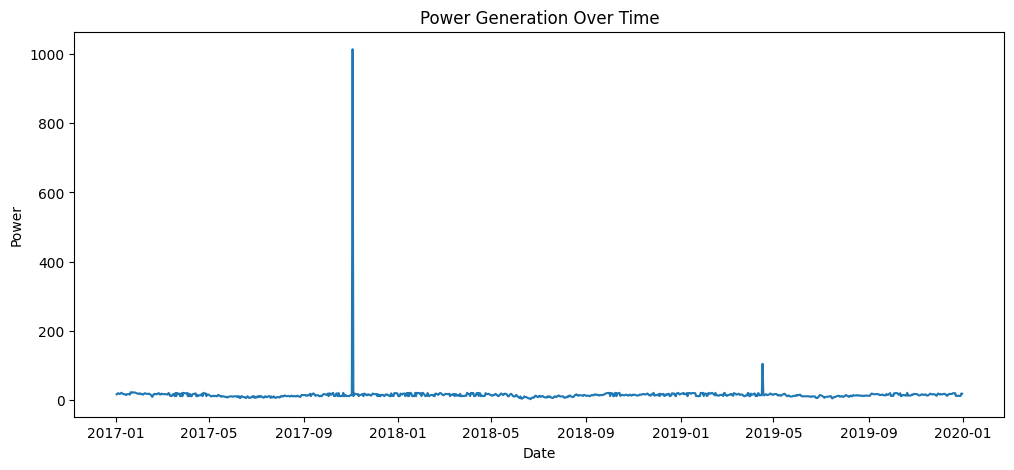

In [2]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['power'])
plt.title("Power Generation Over Time")
plt.xlabel("Date")
plt.ylabel("Power")
plt.show()

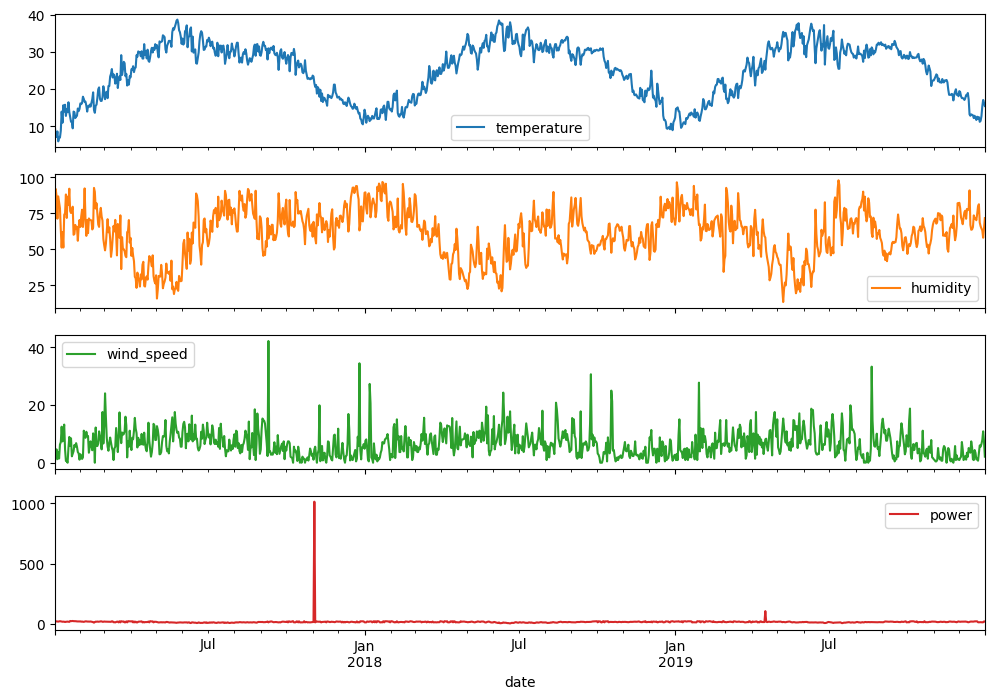

In [3]:
features = ['temperature', 'humidity', 'wind_speed', 'power']

df.set_index('date')[features].plot(subplots=True, figsize=(12,8))
plt.show()

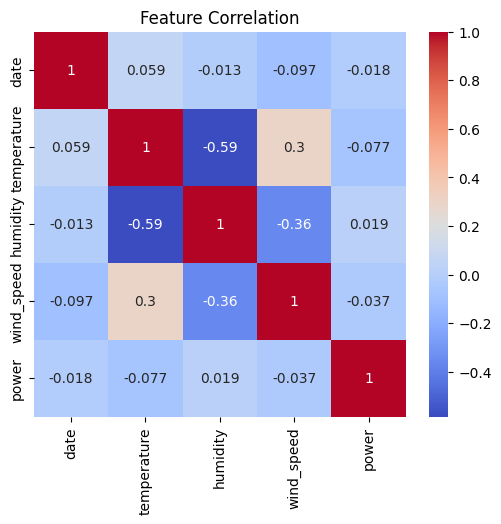

In [4]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

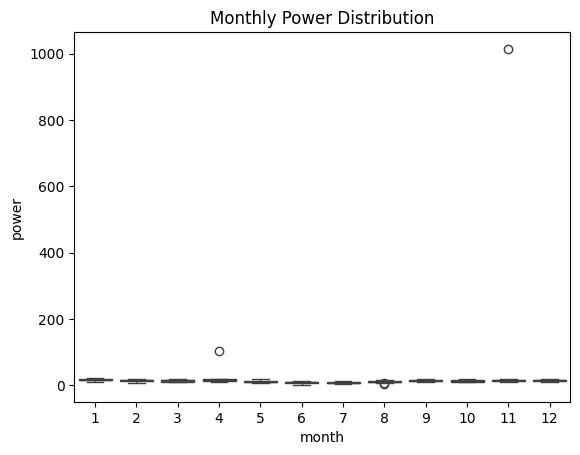

In [5]:
df['month'] = df['date'].dt.month

import seaborn as sns
sns.boxplot(x='month', y='power', data=df)
plt.title("Monthly Power Distribution")
plt.show()

### Model Training and Evaluation 

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================================
# 1. Data Preparation
# ==========================================================
df = pd.read_csv(r"C:\Users\rasik\Downloads\DailyBeijingClimate.csv")
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

features = ['temperature', 'humidity', 'wind_speed', 'power']
df = df[features]

scalers = {}
for column in df.columns:
    scaler = MinMaxScaler()
    df[column] = scaler.fit_transform(df[[column]])
    scalers['scaler_' + column] = scaler

n_past = 10
n_future = 5
n_features = len(features)

X = []
y = []

for i in range(n_past, len(df) - n_future + 1):
    X.append(df.iloc[i - n_past:i].values)
    y.append(df.iloc[i:i + n_future].values)

X = np.array(X)
y = np.array(y)

train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# ==========================================================
# 3. OPTIMIZED LSTM MODEL
# ==========================================================
learning_rate = 0.0005010655467331121
dropout_rate = 0.29784198491913993
units = 20
batch_size = 1

inputs = tf.keras.layers.Input(shape=(n_past, n_features))
lstm = tf.keras.layers.LSTM(units, return_sequences=False)(inputs)
dropout = tf.keras.layers.Dropout(dropout_rate)(lstm)

outputs = tf.keras.layers.Dense(n_features * n_future)(dropout)
outputs = tf.keras.layers.Reshape([n_future, n_features])(outputs)

opt_model1 = tf.keras.models.Model(inputs, outputs)

opt_model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss=tf.keras.losses.Huber()
)

opt_model1.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    verbose=1
)

pred_opt1 = opt_model1.predict(X_test)

# ==========================================================
# 4. INVERSE TRANSFORM (CORRECT)
# ==========================================================

pred_opt_inv1 = pred_opt1.copy()
y_test_inv = y_test.copy()

for idx, feature in enumerate(features):
    scaler = scalers['scaler_' + feature]
    pred_opt_inv1[:, :, idx] = scaler.inverse_transform(pred_opt1[:, :, idx])
    y_test_inv[:, :, idx] = scaler.inverse_transform(y_test[:, :, idx])

# ==========================================================
# 5. FLATTEN FOR METRICS
# ==========================================================
y_true = y_test_inv.flatten()
y_pred_opt1 = pred_opt_inv1.flatten()

# ==========================================================
# 6. METRICS
# ==========================================================
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2:", r2)



Epoch 1/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.0411 - val_loss: 0.0051
Epoch 2/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0107 - val_loss: 0.0048
Epoch 3/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0083 - val_loss: 0.0048
Epoch 4/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0072 - val_loss: 0.0041
Epoch 5/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0061 - val_loss: 0.0041
Epoch 6/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0061 - val_loss: 0.0043
Epoch 7/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0060 - val_loss: 0.0041
Epoch 8/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0056 - val_loss: 0.0040
Epoch 9/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.0053 - val_loss: 0.0041
Epoch 10/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - loss: 0.0051 - val_loss: 0.0040
Epoch 11/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0051 - val_loss: 0.0041
Epoch 12/50
864/864 ━━━━━━━━━━━━━━━━━━━━ 16s 18

In [13]:
opt_model1.save(r"C:\Users\rasik\Downloads\ML_Project\backend\models\lstm_power_model.keras")

In [7]:
import joblib
joblib.dump(scalers, r"C:\Users\rasik\Downloads\ML_Project\backend\models\scalers.pkl")

['C:\\Users\\rasik\\Downloads\\ML_Project\\backend\\models\\scalers.pkl']

In [2]:
evaluate(y_true, y_pred_opt1, "Optimized LSTM")


Optimized LSTM
MAE: 3.877697350847747
MSE: 34.69089428051024
RMSE: 5.889897646013065
R2: 0.9354451389568346


In [8]:
# ==========================================================
# 4. MAKE PREDICTIONS
# ==========================================================

predictions = opt_model1.predict(X_test)


# ==========================================================
# 5. INVERSE TRANSFORM (RETURN TO ORIGINAL SCALE)
# ==========================================================

pred_inv = predictions.copy()
y_test_inv = y_test.copy()

for idx, feature in enumerate(features):
    scaler = scalers['scaler_' + feature]

    pred_inv[:, :, idx] = scaler.inverse_transform(predictions[:, :, idx])
    y_test_inv[:, :, idx] = scaler.inverse_transform(y_test[:, :, idx])


# ==========================================================
# 6. EXTRACT POWER PREDICTIONS (t+1 FORECAST)
# ==========================================================

power_index = features.index("power")

# take only the first future step (t+1)
actual_power = y_test_inv[:, 0, power_index]
predicted_power = pred_inv[:, 0, power_index]


# ==========================================================
# 7. CREATE MATCHING DATES FOR TEST SET
# ==========================================================

test_dates = df.index[train_size + n_past : train_size + n_past + len(actual_power)]


# ==========================================================
# 8. PREPARE DATA FOR DASHBOARD (ACTUAL VS PREDICTED)
# ==========================================================

actual_vs_predicted = []

for i in range(len(actual_power)):
    actual_vs_predicted.append({
        "date": str(test_dates[i].date()),
        "actual": float(actual_power[i]),
        "predicted": float(predicted_power[i])
    })


# ==========================================================
# 9. ERROR DISTRIBUTION
# ==========================================================

errors = actual_power - predicted_power

hist, bins = np.histogram(errors, bins=20)

error_distribution = []

for i in range(len(hist)):
    error_distribution.append({
        "error": float(bins[i]),
        "count": int(hist[i])
    })




7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step 


In [11]:
import json
import os

save_path = r"C:\Users\rasik\Downloads\ML_Project\backend\data"

os.makedirs(save_path, exist_ok=True)

dashboard_data = {
    "actualVsPredicted": actual_vs_predicted,
    "errorDistribution": error_distribution
}

with open(os.path.join(save_path, "dashboard_data.json"), "w") as f:
    json.dump(dashboard_data, f)

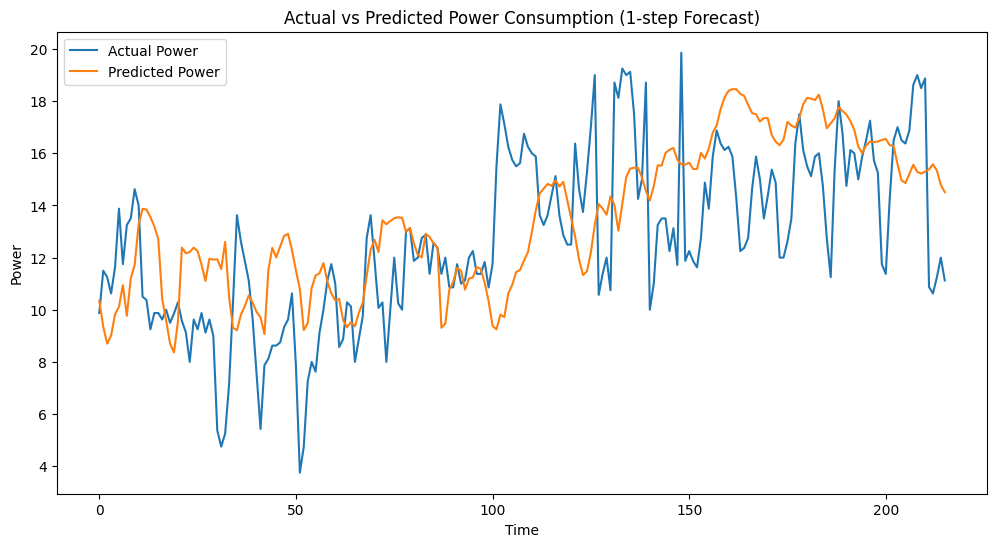

In [14]:
actual_power = y_test_inv[:, 0, 3]      # actual power (day 1 ahead)
predicted_power = pred_opt_inv1[:, 0, 3] # predicted power (day 1 ahead)

plt.figure(figsize=(12,6))
plt.plot(actual_power, label="Actual Power")
plt.plot(predicted_power, label="Predicted Power")

plt.title("Actual vs Predicted Power Consumption (1-step Forecast)")
plt.xlabel("Time")
plt.ylabel("Power")
plt.legend()
plt.show()

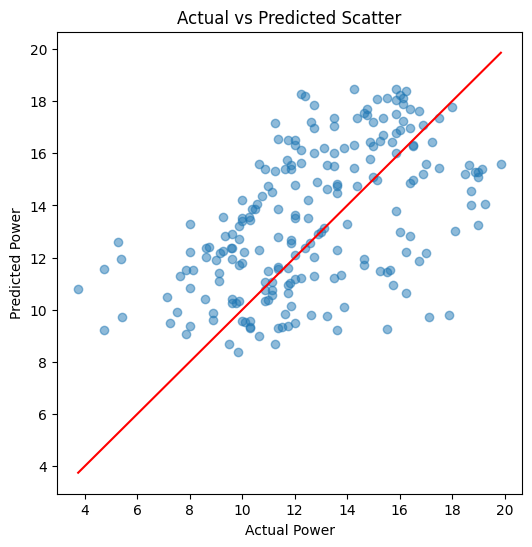

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(actual_power, predicted_power, alpha=0.5)

plt.plot(
    [actual_power.min(), actual_power.max()],
    [actual_power.min(), actual_power.max()],
    'r'
)

plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Scatter")

plt.show()

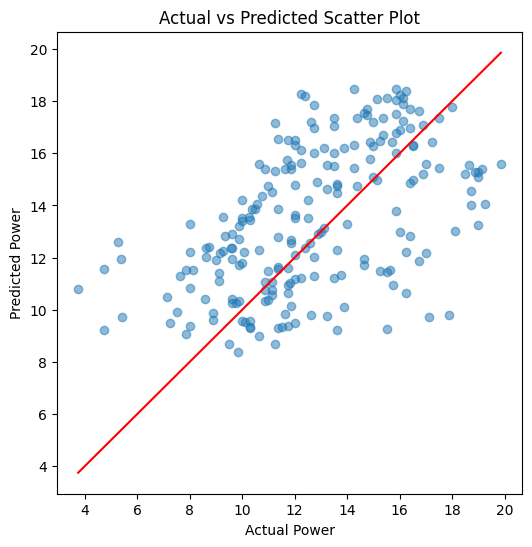

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(actual_power, predicted_power, alpha=0.5)
plt.xlabel("Actual Power")
plt.ylabel("Predicted Power")
plt.title("Actual vs Predicted Scatter Plot")

plt.plot(
    [actual_power.min(), actual_power.max()],
    [actual_power.min(), actual_power.max()],
    'r'
)

plt.show()

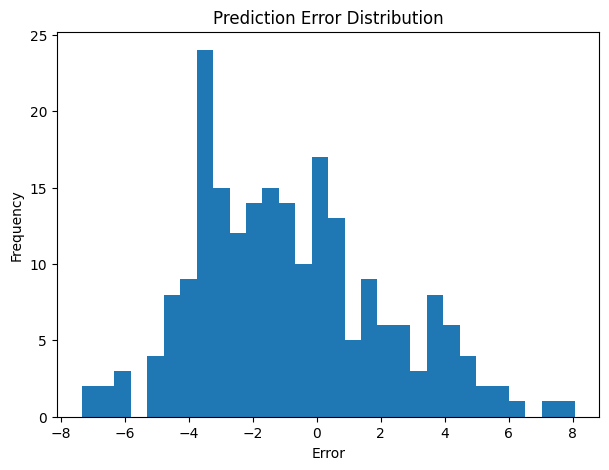

In [17]:
errors = actual_power - predicted_power

plt.figure(figsize=(7,5))
plt.hist(errors, bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

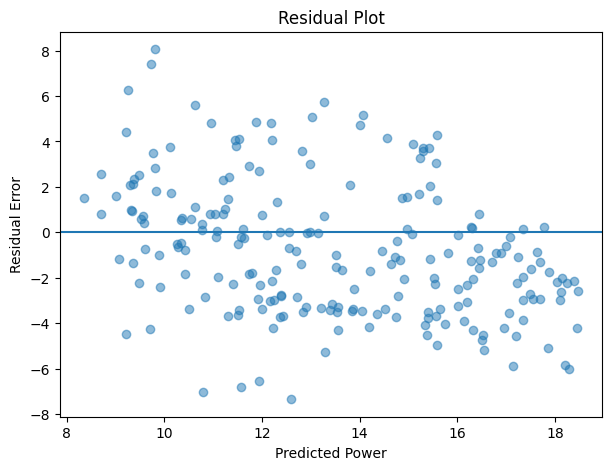

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(predicted_power, errors, alpha=0.5)
plt.axhline(0)
plt.xlabel("Predicted Power")
plt.ylabel("Residual Error")
plt.title("Residual Plot")
plt.show()